<a href="https://colab.research.google.com/github/JunoJames-JJ/Pytorch-/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Deep learning with Pytorch**
Submitted by: Juno Vattakavil James


### **Autoencoders**
- Implement denoising autoencoder for RGB images.
- For this we want to use CIFAR10 dataset.
- You need to add noise to the images before you feed them to the network. This can be done as follows:

        ## add random noise to the input images
        noisy_imgs = images + noise_factor * torch.randn(*images.shape)
        # Clip the images to be between 0 and 1
        noisy_imgs = np.clip(noisy_imgs, 0., 1.)

- Make sure to display samples of the images before and after adding noise.



#### **Importing libraries**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

#### **Dataset Loading**

In [ ]:
transform = transforms.ToTensor()

train_data = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([8, 3, 32, 32])
torch.Size([8])


#### **Visualizing the batch**

In [ ]:
import matplotlib.pyplot as plt

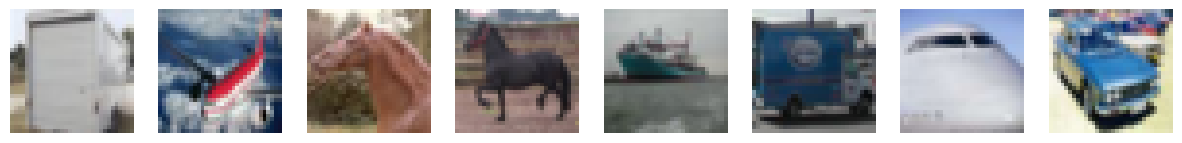

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(15, 3))

for i in range(8):
    img = images[i].permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()

#### **Adding Noise**

In [ ]:
noise_factor = 0.2

## add random noise to the input images
noisy_imgs = images + noise_factor * torch.randn(*images.shape)

# clip the images to be between 0 and 1
noisy_imgs = np.clip(noisy_imgs, 0., 1.)

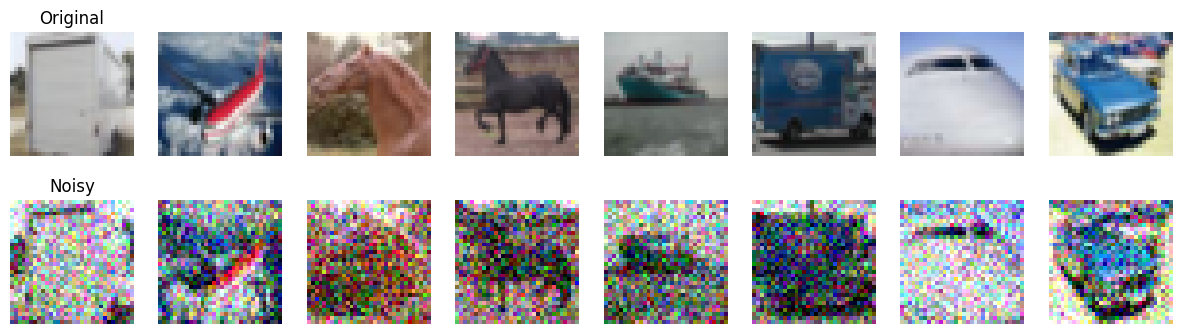

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(15, 4))

for i in range(8):
    # original
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].axis('off')

    # noisy
    axes[1, i].imshow(noisy_imgs[i].permute(1, 2, 0))
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Noisy")

plt.show()

*Noise is added to the images using Gaussian noise to train the autoencoder to reconstruct the original images.*

#### **Denoising Autoencoder**

In [ ]:
import torch.nn as nn

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
model = DenoisingAutoencoder()
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


#### **Training**

In [ ]:
import torch.optim as optim

In [ ]:
#loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

*Mean Squared Error loss is used to measure the difference between reconstructed and original images.*

In [ ]:
epochs = 5
noise_factor = 0.2

for epoch in range(epochs):
    running_loss = 0.0

    for images, _ in train_loader:


        # add random noise to the input images
        noisy_imgs = images + noise_factor * torch.randn(*images.shape)

        # clip the images to be between 0 and 1
        noisy_imgs = np.clip(noisy_imgs, 0., 1.)

        # forward pass
        outputs = model(noisy_imgs)
        loss = criterion(outputs, images)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 47.3693
Epoch [2/5], Loss: 35.4212
Epoch [3/5], Loss: 33.4874
Epoch [4/5], Loss: 32.6529
Epoch [5/5], Loss: 32.1580


#### **Testing**

In [ ]:
test_data = datasets.CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

In [ ]:
images, _ = next(iter(test_loader))

In [ ]:
# Adding noise
noise_factor = 0.2

noisy_imgs = images + noise_factor * torch.randn(*images.shape)

noisy_imgs = np.clip(noisy_imgs, 0., 1.)

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(noisy_imgs)

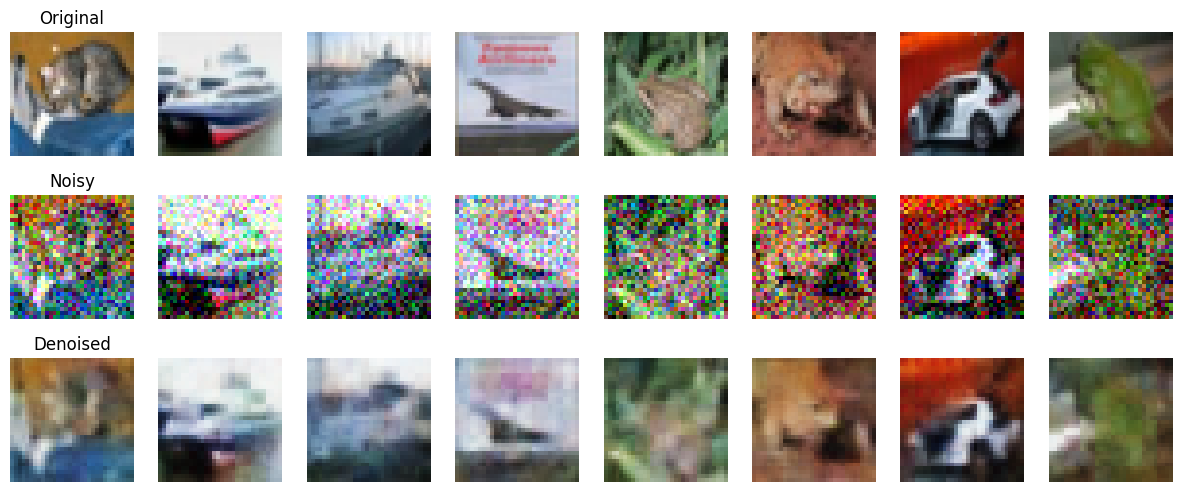

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(15, 6))

for i in range(8):
    # original
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].axis('off')

    # noisy
    axes[1, i].imshow(noisy_imgs[i].permute(1, 2, 0))
    axes[1, i].axis('off')

    # denoised
    axes[2, i].imshow(outputs[i].permute(1, 2, 0))
    axes[2, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Noisy")
axes[2, 0].set_title("Denoised")

plt.show()

*The denoising autoencoder successfully learned to reconstruct clean images from noisy inputs. Although the reconstructed images are slightly blurred, the model effectively removes the noise and preserves the main structure of the images.*